In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [2]:
df = pd.read_csv("../data/dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (3500, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.926425,0.999990,0.999979,0.768649,0.895991,0.594854,0.799972,0.550821,0.700986,0.576920,...,1.015724,0.169606,0.316210,0.152533,0.257643,0.001037,0.260297,0.540918,0.777677,FULL_SCREEN
1,0.978679,0.999991,0.999980,0.740203,0.844386,0.552157,0.608887,0.510736,0.405343,0.546287,...,0.956097,0.152978,0.295672,0.142754,0.126738,0.001011,0.230817,0.473536,0.668609,FULL_SCREEN
2,0.973929,0.999994,0.999985,0.779285,0.774892,0.607912,0.478671,0.589582,0.255136,0.641756,...,0.833845,0.152635,0.283736,0.131424,0.527695,0.001182,0.429287,0.623240,0.769556,FULL_SCREEN
3,0.963197,0.999994,0.999986,0.784358,0.803809,0.607377,0.526255,0.572982,0.304485,0.615199,...,0.817536,0.127737,0.245455,0.119034,0.452885,0.001176,0.471418,0.633226,0.745908,FULL_SCREEN
4,0.969365,0.999994,0.999985,0.783473,0.794224,0.611782,0.502144,0.580884,0.271866,0.620078,...,0.819030,0.130047,0.240817,0.110882,0.458612,0.001156,0.439429,0.606657,0.726746,FULL_SCREEN


In [3]:
# Cột cuối là label
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Số class:", y.nunique())
print(y.value_counts())

Số class: 7
57
FULL_SCREEN    500
MUTE           500
PLAY_PAUSE     500
SEEK_BW        500
SEEK_FW        500
VOL_DOWN       500
VOL_UP         500
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2800, 57)
Test size: (700, 57)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True
)

model.fit(X_train, y_train)

SVC(C=10, probability=True)

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9914285714285714

Classification Report:
              precision    recall  f1-score   support

 FULL_SCREEN       1.00      0.98      0.99       100
        MUTE       1.00      0.99      0.99       100
  PLAY_PAUSE       1.00      1.00      1.00       100
     SEEK_BW       0.97      0.99      0.98       100
     SEEK_FW       0.98      1.00      0.99       100
    VOL_DOWN       1.00      0.98      0.99       100
      VOL_UP       0.99      1.00      1.00       100

    accuracy                           0.99       700
   macro avg       0.99      0.99      0.99       700
weighted avg       0.99      0.99      0.99       700



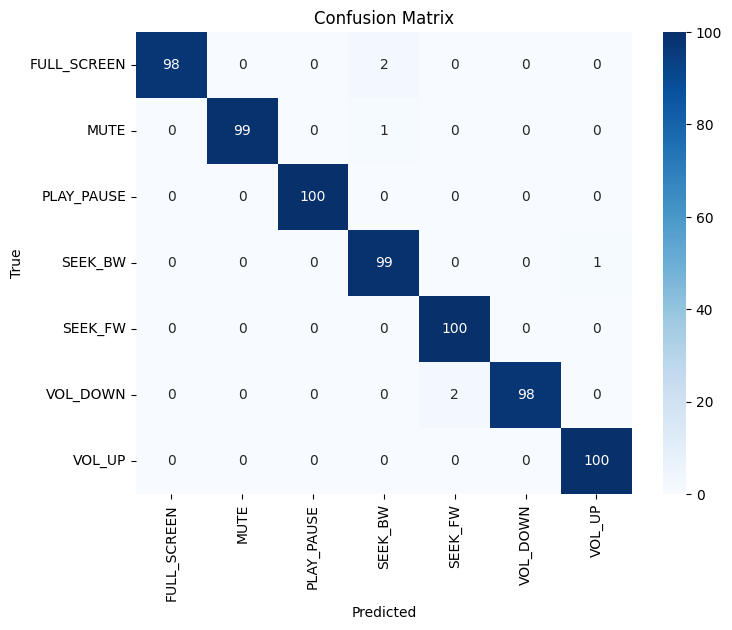

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [9]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=5, verbose=1, n_jobs=-1)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [10]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy sau tuning:", accuracy_score(y_test, y_pred))

Accuracy sau tuning: 0.9871428571428571


In [12]:
BASE_PATH = "../models"
os.makedirs(BASE_PATH, exist_ok=True)

model_path = os.path.join(BASE_PATH, "hand_gesture_svm.pkl")

joblib.dump({
    'model': model,
    'scaler': scaler
}, model_path)

print("Đã lưu model tại:", model_path)

Đã lưu model tại: ../models\hand_gesture_svm.pkl
